ML – MIDTERM EXAM (100 Marks)

This notebook is your **single submission file** for the Midterm.

- **Total marks:** 100  
  - Section A: 40 marks  
  - Section B: 60 marks  
- Answer **all questions** in this notebook.  
- Do **not** create a separate PDF.  
- Use clear headings, code, and explanations.

- Run all cells before submitting so all outputs are visible.
- Set the Colab file's shareable link to ‘Anyone with the link’ and ‘View’ access, then submit it in the Phitron Assignment module's Assignment submission section.

In [17]:
# Common imports for Section B (run once)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, roc_curve, auc

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

plt.rcParams['figure.figsize'] = (6, 4)
plt.rcParams['axes.grid'] = True

---

## SECTION A – Short Application Questions (40 Marks)

Write your answers in the provided **answer cells** in this notebook. Use text, formulas, and short reasoning.

Marks for each question are clearly mentioned.

---

### Q1. Descriptive Statistics and Distributions (15 marks)

A dataset of monthly customer spending (in dollars) is:

`[30, 35, 32, 34, 33, 500, 31, 34, 32, 33]`

1. Compute the **median** and **IQR**. Show your working clearly.  
2. Use the **IQR rule** to check if 500 is an outlier. Show your steps and the fences.  
3. Explain in 3 to 5 sentences why **median + IQR** may be better than **mean + standard deviation** for this dataset.

Write your full answer in the cell below.


#### Q1 Answer (Student)

_Write your calculations and explanation here. You may use Python below if you want, but final reasoning must be readable._

In [18]:
# Optional helper code for Q1 (not required)
data_q1 = [30, 35, 32, 34, 33, 500, 31, 34, 32, 33]
data_q1

[30, 35, 32, 34, 33, 500, 31, 34, 32, 33]

In [19]:
# 1 number:

sorted_data=sorted(data_q1)
print("Sorted data :",sorted_data)

median=np.median(sorted_data)
print("Median:",median)

Q1=np.percentile(sorted_data,25)
Q3=np.percentile(sorted_data,75)
print("Q1:",Q1)
print("Q3:",Q3)

IQR=Q3-Q1
print("IQR:",IQR)

Sorted data : [30, 31, 32, 32, 33, 33, 34, 34, 35, 500]
Median: 33.0
Q1: 32.0
Q3: 34.0
IQR: 2.0


In [20]:
# 2 number :

lower_fence=Q1 -1.5*IQR
upper_fence=Q3+1.5*IQR

print("Lower fence:",lower_fence)
print("Upper fence:",upper_fence)

if 500< lower_fence or 500> upper_fence:
    print("500 is an outlier.")
else:
    print("500 is not an outlier.")    

Lower fence: 29.0
Upper fence: 37.0
500 is an outlier.


### 3. Why Median + IQR is Better .

This dataset contains an extreme value (500), which heavily affects the mean and standard deviation, making them misleading. The median is resistant to extreme values and gives a better measure of the central tendency. Similarly, the IQR describes the spread of the middle 50% of the data and ignores outliers. Therefore, median and IQR provide a more accurate and reliable summary of this dataset than mean and standard deviation.

### Q2. Bayes and Probability in ML (10 marks)

A disease affects **1 percent** of people.  
A test has:  
- Sensitivity: **90 percent**  
- Specificity: **92 percent**  

A random person tests positive.

1. Compute the **positive predictive value (PPV)** using Bayes theorem. Show all steps with probabilities.  
2. If prevalence rises to **20 percent**, explain in 3 to 4 sentences whether PPV increases or decreases and why. You may refer to the Bayes formula in words.

Write your full answer in the cell below.


#### Q2 Answer (Student)

_Write your step by step Bayes calculation and explanation here._

In [21]:
### Q2 --> 1 num :

prevalence = 0.01
sensitivity = 0.90
specificity = 0.92

fpr = 1 - specificity

ppv = (sensitivity * prevalence) / ((sensitivity * prevalence) + (fpr * (1 - prevalence)))
ppv

0.10204081632653066

### Q2--> 2 num:

PPV =(Sensitivity * Prevalence)/ ((Sensitivity×Prevalence)+(False Positive Rate×(1−Prevalence))	​)

- When prevalence increases, the numerator (Sensitivity × Prevalence) becomes larger.

- The false positive part in the denominator ((1 − Specificity) × (1 − Prevalence)) becomes smaller.

- Therefore, a positive test is more likely to indicate the disease.

### Q3. ML Pipeline Thinking (15 marks)

Columns in a new dataset:

- `age` (numeric)  
- `region` (categorical with 7 levels)  
- `daily_clicks` (numeric)  
- `premium_user` (0 or 1 target)

1. Identify the **type of ML task**. (1 or 2 lines)  
2. List **four preprocessing steps** that would be reasonable for this dataset. (bullet points are fine)  
3. In one short paragraph (6 to 8 sentences), describe the **end to end ML pipeline** you would follow for this problem, from raw data to model evaluation.

Write your full answer in the cell below.


#### Q3 Answer (Student)

_Write your task type, preprocessing list, and pipeline paragraph here._



1 num :
This is a binary classification task because the target premium_user has two possible values: 0 or 1.


2 num:
- Handle missing values for numeric features (age, daily_clicks) and categorical feature (region).
- Encode the categorical feature region using one-hot encoding.
- Scale/normalize numeric features (age and daily_clicks) to ensure comparability.
- Split the dataset into training and testing sets for model evaluation.


3 num :
First, I would check the dataset for missing values or outliers and handle them appropriately.
Next, I would encode the categorical feature region using one-hot encoding and scale the numeric features age and daily_clicks.
Then, I would split the data into training and testing sets to evaluate model performance.
I would train a classification model, such as Logistic Regression or Random Forest, on the training set.
Finally, I would evaluate the model using metrics like accuracy, precision, recall, and F1-score, and fine-tune it if needed.


---

## SECTION B – Applied Coding Problems (60 Marks)

Answer **all three questions** in this section.

- Write clean, commented code.  
- After each main step, add a short markdown explanation of what you did and what you observe.  
- Make sure all plots are visible in the notebook.

Marks for each question are clearly mentioned.

---

### Q4. Applied EDA and Preprocessing (20 marks)

We work with the following dataset:

```python
import pandas as pd

df = pd.DataFrame({
    "age": [25, 30, None, 22, 45, 52, None],
    "region": ["north","south","north","east","west","west","south"],
    "purchases": [3, 10, 5, None, 20, 18, 9],
    "premium_user": [0,1,0,0,1,1,0]
})
```

**Tasks (20 marks total):**

1. **Compact EDA using pandas** (6 marks)  
   - Show missing value summary for each column.  
   - Show number of unique values per column.  
   - Show correlation among numeric columns.  
   - Plot:  
     - A histogram of `purchases`.  
     - A bar chart for `region` frequency.

2. **Preprocess the dataset using sklearn plus pandas** (9 marks)  
   - Impute `age` with **median**.  
   - Impute `purchases` with **mean**.  
   - One hot encode `region`.  
   - Scale all numeric columns using **RobustScaler**.

3. **Create one domain driven feature** (3 marks)  
   - Example ideas: `high_spender` based on `purchases`, or `age_group` bins, or an interaction like `age * purchases`.

4. Show the **final transformed dataframe** ready for model training. (2 marks)

Use short explanations in markdown to describe each main block of code.


In [37]:
# Q4 – Student Answer

# Step 1: Create the dataframe
df = pd.DataFrame({
    "age": [25, 30, None, 22, 45, 52, None],
    "region": ["north","south","north","east","west","west","south"],
    "purchases": [3, 10, 5, None, 20, 18, 9],
    "premium_user": [0,1,0,0,1,1,0]
})

df

,age,region,purchases,premium_user
0,25.0,north,3.0,0
1,30.0,south,10.0,1
2,NaN,north,5.0,0
3,22.0,east,NaN,0
4,45.0,west,20.0,1
5,52.0,west,18.0,1
6,NaN,south,9.0,0


In [23]:
# 1a. Missing value summary
print("Missing values per column:")
print(df.isna().sum())


Missing values per column:
age             2
region          0
purchases       1
premium_user    0
dtype: int64


In [24]:
# 1b. Number of unique values per column
print("Unique values per column:")
print(df.nunique())



Unique values per column:
age             5
region          4
purchases       6
premium_user    2
dtype: int64


In [25]:
# 1c. Correlation among numeric columns
print("Correlation among numeric columns:")
print(df.select_dtypes(include='number').corr())

Correlation among numeric columns:
                   age  purchases  premium_user
age           1.000000   0.923677      0.789534
purchases     0.923677   1.000000      0.825860
premium_user  0.789534   0.825860      1.000000


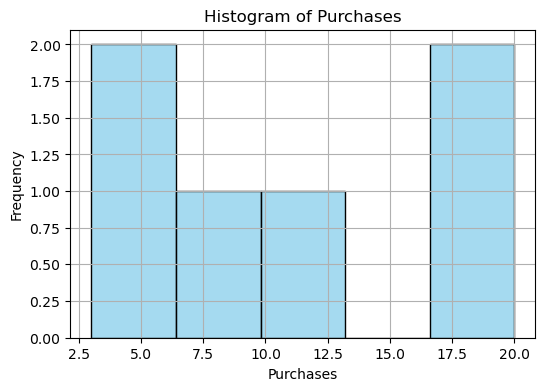

In [26]:
# 1d. Plot histogram of purchases

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.histplot(df['purchases'], bins=5, kde=False, color='skyblue')
plt.title("Histogram of Purchases")
plt.xlabel("Purchases")
plt.ylabel("Frequency")
plt.show()




/tmp/ipykernel_24856/2276165824.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='region', palette='Set2')


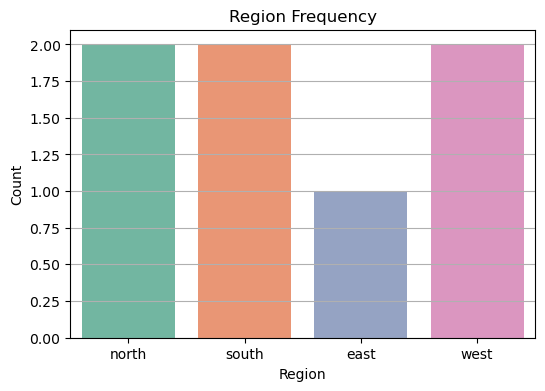

In [27]:
# 1e. Bar chart for region frequency
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='region', palette='Set2')
plt.title("Region Frequency")
plt.xlabel("Region")
plt.ylabel("Count")
plt.show()

In [42]:
# num 2
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler

df = pd.DataFrame({
    "age": [25, 30, None, 22, 45, 52, None],
    "region": ["north","south","north","east","west","west","south"],
    "purchases": [3, 10, 5, None, 20, 18, 9],
    "premium_user": [0,1,0,0,1,1,0]
})

# Impute missing values
age_imputer = SimpleImputer(strategy='median')
df['age'] = age_imputer.fit_transform(df[['age']])

purchases_imputer = SimpleImputer(strategy='mean')
df['purchases'] = purchases_imputer.fit_transform(df[['purchases']])

#  One hot encode 'region'
ohe = OneHotEncoder(sparse_output=False, drop='first')
region_encoded = ohe.fit_transform(df[['region']])
region_df = pd.DataFrame(region_encoded, columns=ohe.get_feature_names_out(['region']))

df = pd.concat([df.drop('region', axis=1), region_df], axis=1)

#  Scale numeric columns
scaler = RobustScaler()
numeric_cols = ['age', 'purchases']
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

# Final dataframe
print(df)


   age  purchases  premium_user  region_north  region_south  region_west
0 -0.5  -0.943820             0           1.0           0.0          0.0
1  0.0   0.000000             1           0.0           1.0          0.0
2  0.0  -0.674157             0           1.0           0.0          0.0
3 -0.8   0.112360             0           0.0           0.0          0.0
4  1.5   1.348315             1           0.0           0.0          1.0
5  2.2   1.078652             1           0.0           0.0          1.0
6  0.0  -0.134831             0           0.0           1.0          0.0


In [ ]:
# 3 num answer : Domain-driven feature

purchase_threshold = df['purchases'].median()

df['high_spender'] = (df['purchases'] > purchase_threshold).astype(int)
df


,age,purchases,premium_user,region_north,region_south,region_west,high_spender
0,-0.5,-0.943820,0,1.0,0.0,0.0,0
1,0.0,0.000000,1,0.0,1.0,0.0,0
2,0.0,-0.674157,0,1.0,0.0,0.0,0
3,-0.8,0.112360,0,0.0,0.0,0.0,1
4,1.5,1.348315,1,0.0,0.0,1.0,1
5,2.2,1.078652,1,0.0,0.0,1.0,1
6,0.0,-0.134831,0,0.0,1.0,0.0,0


In [44]:
# 4 num
print("Final transformed dataframe:")
print(df)


Final transformed dataframe:
   age  purchases  premium_user  region_north  region_south  region_west  \
0 -0.5  -0.943820             0           1.0           0.0          0.0   
1  0.0   0.000000             1           0.0           1.0          0.0   
2  0.0  -0.674157             0           1.0           0.0          0.0   
3 -0.8   0.112360             0           0.0           0.0          0.0   
4  1.5   1.348315             1           0.0           0.0          1.0   
5  2.2   1.078652             1           0.0           0.0          1.0   
6  0.0  -0.134831             0           0.0           1.0          0.0   

   high_spender  
0             0  
1             0  
2             0  
3             1  
4             1  
5             1  
6             0  


_Use additional code cells below for EDA, preprocessing, feature engineering, and final dataframe. Add brief explanations in markdown between code blocks._

---

### Q5. Applied Regression and Residual Analysis (20 marks)

We use this dataset:

```python
import pandas as pd

df2 = pd.DataFrame({
    "area_sqft": [800, 1000, 1200, 1500, 1800, 2000],
    "bedrooms": [2,2,3,3,4,4],
    "price": [120, 150, 170, 210, 260, 300]
})
```

**Tasks (20 marks total):**

1. Create the dataframe `df2`. (1 mark)  
2. Split the data into **train and test** with 80 percent train and 20 percent test. (3 marks)  
3. Fit a **LinearRegression** model to predict `price` from `area_sqft` and `bedrooms`. (4 marks)  
4. Print model **intercept**, **coefficients**, and **predictions** on the test set. (4 marks)  
5. Compute the following metrics on the test set. (6 marks)  
   - Mean Absolute Error (MAE)  
   - Root Mean Squared Error (RMSE)  
   - R squared (R²)  
6. Plot a **residual plot** with `y_true − y_pred` on the vertical axis and `y_pred` on the horizontal axis. (2 marks)  
   - Add a short note explaining what you observe from the residuals.

Again, use short markdown explanations to describe each step.


In [45]:
# Q5 – Student Answer

# Step 1: Create the dataframe
df2 = pd.DataFrame({
    "area_sqft": [800, 1000, 1200, 1500, 1800, 2000],
    "bedrooms": [2,2,3,3,4,4],
    "price": [120, 150, 170, 210, 260, 300]
})

df2

,area_sqft,bedrooms,price
0,800,2,120
1,1000,2,150
2,1200,3,170
3,1500,3,210
4,1800,4,260
5,2000,4,300


In [46]:
from sklearn.model_selection import train_test_split

X = df2[["area_sqft", "bedrooms"]]
y = df2["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train, X_test


(   area_sqft  bedrooms
 5       2000         4
 2       1200         3
 4       1800         4
 3       1500         3,
    area_sqft  bedrooms
 0        800         2
 1       1000         2)

In [47]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [48]:
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

y_pred = model.predict(X_test)
print("Predictions:", y_pred)


Intercept: -33.84615384615387
Coefficients: [0.15384615 5.38461538]
Predictions: [100.         130.76923077]


In [49]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)


MAE: 19.615384615384613
RMSE: 19.61915499208746
R²: -0.7107166337935567


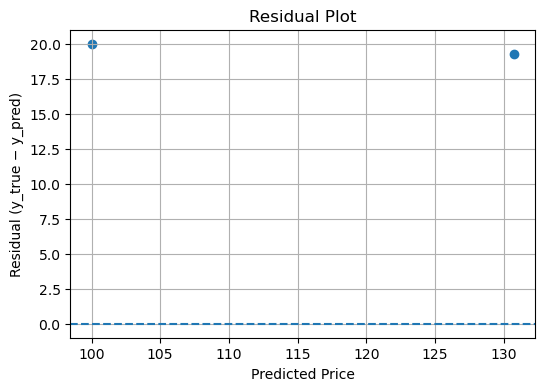

In [50]:
import matplotlib.pyplot as plt

residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(0, linestyle='--')
plt.xlabel("Predicted Price")
plt.ylabel("Residual (y_true − y_pred)")
plt.title("Residual Plot")
plt.show()


_Use additional code cells below for train test split, model training, metrics, and the residual plot. Add a brief comment on the residuals in markdown._

---

### Q6. Applied Classification, Metrics, Trees and ROC (20 marks)

We start with:

```python
import numpy as np

y_true = np.array([1,0,1,0,1,0,1,0,1,0])
y_prob = np.array([0.9,0.1,0.85,0.2,0.7,0.4,0.6,0.3,0.95,0.05])
```

**Part 1: Threshold based classification and metrics (8 marks)**

1. With threshold **0.5**, convert probabilities to class predictions. Then compute:  
   - Confusion matrix  
   - Precision  
   - Recall  
   - F1 score

2. With threshold **0.3**, convert probabilities to class predictions again and recompute the same metrics.

3. In 3 to 4 sentences, explain how lowering the threshold from 0.5 to 0.3 changed precision and recall and why this happens.

**Part 2: ROC and AUC (6 marks)**

4. Plot the **ROC curve** using `y_true` and `y_prob`.  
5. Compute the **AUC** and print it with 3 decimal places.  
6. Add a one or two line comment on what a high or low AUC means in this context.

**Part 3: Decision Tree on a small dataset (6 marks)**

Create this dataset:

```python
df3 = pd.DataFrame({
    "hours": [1,2,3,4,5,1,2,3,4,5],
    "passed": [0,0,0,1,1,0,0,1,1,1]
})
```

7. Fit a `DecisionTreeClassifier(max_depth=2)` to predict `passed` from `hours`.  
8. Plot the tree using `plot_tree`.  
9. Write 2 to 3 lines explaining whether the tree looks like it might **overfit** or **generalize well**, given the dataset size and the model depth.


In [61]:
# Q6 – Student Answer

# Part 1: threshold based classification
y_true = np.array([1,0,1,0,1,0,1,0,1,0])
y_prob = np.array([0.9,0.1,0.85,0.2,0.7,0.4,0.6,0.3,0.95,0.05])

# Write your code for threshold 0.5 and 0.3 below

from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

### Threshold = 0.5
y_pred_05 = (y_prob >= 0.5).astype(int)

print("Confusion Matrix:", confusion_matrix(y_true, y_pred_05))
print("Precision:", precision_score(y_true, y_pred_05))
print("Recall:", recall_score(y_true, y_pred_05))
print("F1 Score:", f1_score(y_true, y_pred_05))

### Threshold = 0.3
y_pred_03 = (y_prob >= 0.3).astype(int)

print("Confusion Matrix:", confusion_matrix(y_true, y_pred_03))
print("Precision:", precision_score(y_true, y_pred_03))
print("Recall:", recall_score(y_true, y_pred_03))
print("F1 Score:", f1_score(y_true, y_pred_03))


Confusion Matrix: [[5 0]
 [0 5]]
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
Confusion Matrix: [[3 2]
 [0 5]]
Precision: 0.7142857142857143
Recall: 1.0
F1 Score: 0.8333333333333334


In [54]:
threshold = 0.5
y_pred_05 = (y_prob >= threshold).astype(int)

cm_05 = confusion_matrix(y_true, y_pred_05)
prec_05 = precision_score(y_true, y_pred_05)
rec_05 = recall_score(y_true, y_pred_05)
f1_05 = f1_score(y_true, y_pred_05)

print("Threshold 0.5")
print("Confusion Matrix:\n", cm_05)
print("Precision:", prec_05)
print("Recall:", rec_05)
print("F1 Score:", f1_05)


Threshold 0.5
Confusion Matrix:
 [[5 0]
 [0 5]]
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


In [55]:
threshold = 0.3
y_pred_03 = (y_prob >= threshold).astype(int)

cm_03 = confusion_matrix(y_true, y_pred_03)
prec_03 = precision_score(y_true, y_pred_03)
rec_03 = recall_score(y_true, y_pred_03)
f1_03 = f1_score(y_true, y_pred_03)

print("\nThreshold 0.3")
print("Confusion Matrix:\n", cm_03)
print("Precision:", prec_03)
print("Recall:", rec_03)
print("F1 Score:", f1_03)



Threshold 0.3
Confusion Matrix:
 [[3 2]
 [0 5]]
Precision: 0.7142857142857143
Recall: 1.0
F1 Score: 0.8333333333333334


3 num

Lowering the threshold makes the classifier label more samples as positive. This generally increases recall because more actual positives are correctly captured. However, precision may decrease since more false positives are introduced. This trade-off is typical: making the model more “sensitive” usually reduces its “specificity.”

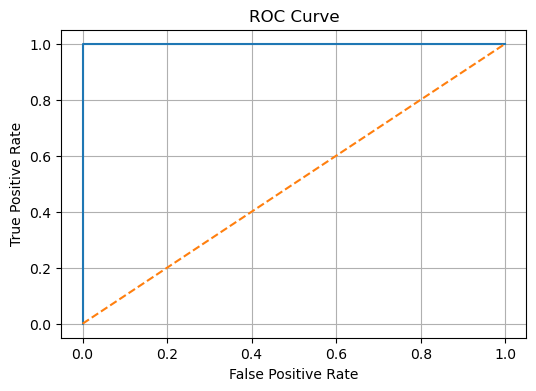

AUC: 1.000


In [ ]:
# part -- 2
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_true, y_prob)

# Plot
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

# Compute AUC
roc_auc = auc(fpr, tpr)
print("AUC:", f"{roc_auc:.3f}")


### 6 num

A high AUC means the model is very good at separating positive and negative classes across all thresholds. A low AUC would indicate weak discriminative ability.

In [57]:
# part - 3

import pandas as pd

df3 = pd.DataFrame({
    "hours": [1,2,3,4,5,1,2,3,4,5],
    "passed": [0,0,0,1,1,0,0,1,1,1]
})


In [58]:
from sklearn.tree import DecisionTreeClassifier

X3 = df3[['hours']]
y3 = df3['passed']

tree = DecisionTreeClassifier(max_depth=2, random_state=42)
tree.fit(X3, y3)


DecisionTreeClassifier(max_depth=2, random_state=42)

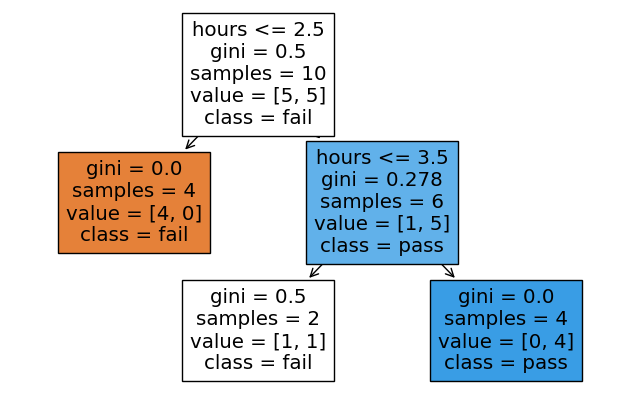

In [59]:
from sklearn.tree import plot_tree

plt.figure(figsize=(8,5))
plot_tree(tree, feature_names=['hours'], class_names=['fail','pass'], filled=True)
plt.show()


9 num:

The tree has only depth 2, which restricts its complexity and helps prevent overfitting. Given the very small dataset, this level of depth is appropriate and the tree is likely to generalize reasonably well. A deeper tree might memorize individual points, but here the structure remains simple and interpretable.

_Add more code cells for ROC and AUC, and for the decision tree on df3. Write your short explanations in markdown after the relevant outputs._